In [ ]:
#Downloading Libraries

In [2]:
!pip install textblob --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from textblob import TextBlob

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Libraries downloaded successfully!")

1072.81s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/aimeerim/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/aimeerim/nltk_data...
[nltk_data] Downloading package omw-1.4 to /home/aimeerim/nltk_data...


Libraries downloaded successfully!


In [ ]:
#reading the dataset

In [8]:
df = pd.read_excel('../data/depression-data-set-kaggle.xlsx')
print("📊 Data Set Size:", df.shape)
print("\n📋 Columns:", df.columns.tolist())
print("\n🔍 The first 5 rows:")
print(df.head())
print("Dataset loaded successfully!")

📊 Data Set Size: (7489, 5)

📋 Columns: ['text', 'label', 'Age', 'Gender', 'Age Category']

🔍 The first 5 rows:
                                                text  label   Age  Gender  \
0                               let Gather For Party    0.0  16.0    Male   
1    I hate being alive when I feel so dead inside.     1.0  17.0  Female   
2  Exam are Comimg I  m already  Feeling Very Dep...    1.0  16.0    Male   
3                                       Nice picture    0.0  16.0    Male   
4  Feeling worried, even though you actually have...    1.0  16.0    Male   

  Age Category  
0     Teen Age  
1     Teen Age  
2     Teen Age  
3     Teen Age  
4     Teen Age  
Dataset loaded successfully!


In [12]:
#General Information about the dataset
print("📊 Dataset Size:", df.shape)

print("\n📋 Column Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🏷️ Label Distribution:")
print(df['label'].value_counts())

📊 Dataset Size: (7489, 5)

📋 Column Types:
text             object
label           float64
Age             float64
Gender           object
Age Category     object
dtype: object

❓ Missing Values:
text            13
label            3
Age              3
Gender           3
Age Category     3
dtype: int64

🏷️ Label Distribution:
label
0.0    6259
1.0    1227
Name: count, dtype: int64


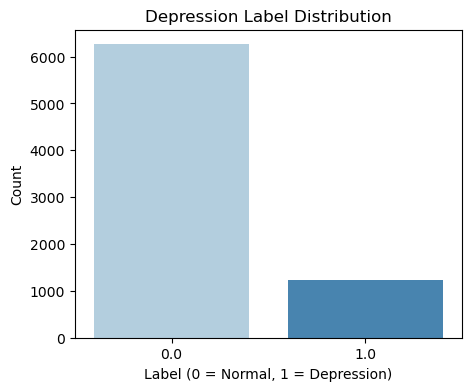

In [13]:
# Label distribution visualization
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='Blues')

plt.title('Depression Label Distribution')
plt.xlabel('Label (0 = Normal, 1 = Depression)')
plt.ylabel('Count')

plt.show()

In [14]:
# Remove missing values
df = df.dropna(subset=['text', 'label'])

# Reset index after cleaning
df = df.reset_index(drop=True)

print("Dataset size after cleaning:", df.shape)

Dataset size after cleaning: (7476, 5)


In [15]:
# Expand keyword lists
def get_severity_v3(row):
    text = str(row['text']).lower()
    label = row['label']

    severe_words = ['hopeless', 'suicide', 'die', 'kill', 'worthless',
                    'end my life', 'give up', 'no reason to live',
                    'cant go on', 'nothing matters', 'want to disappear']

    moderate_words = ['depressed', 'anxious', 'lonely', 'sad', 'crying',
                      'empty', 'tired', 'exhausted', 'miserable', 'lost',
                      'broken', 'hurt', 'pain', 'suffer', 'struggle']

    mild_words = ['stress', 'worried', 'nervous', 'upset', 'confused',
                  'unhappy', 'disappointed', 'frustrated', 'overwhelmed',
                  'exam', 'pressure', 'difficult', 'hard time']

    if label == 1.0:
        if any(w in text for w in severe_words):
            return 'Severe'
        elif any(w in text for w in moderate_words):
            return 'Moderate'
        else:
            return 'Mild'
    else:
        if any(w in text for w in mild_words):
            return 'Mild'
        else:
            return 'Minimal'

df['severity_v3'] = df.apply(get_severity_v3, axis=1)

print("🏷️ New Severity Distribution:")
print(df['severity_v3'].value_counts())

🏷️ New Severity Distribution:
severity_v3
Minimal     6115
Mild         932
Moderate     268
Severe       161
Name: count, dtype: int64


In [17]:
#Text Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove non-letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return ' '.join(words)

df['clean_text'] = df['text'].apply(preprocess_text)

print("Preprocessing completed!")
print("\nExample original text:")
print(df['text'][0])
print("\nCleaned text:")
print(df['clean_text'][0])

Preprocessing completed!

Example original text:
let Gather For Party

Cleaned text:
let gather party


In [ ]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE

# TF-IDFf
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['severity_v3']

print("Class distribution before SMOTE:")
print(y.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nClass distribution after SMOTE:")
import pandas as pd
print(pd.Series(y_resampled).value_counts())

3023.62s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
📊 Class distribution before SMOTE:
severity_v3
Minimal     6115
Mild         932
Moderate     268
Severe       161
Name: count, dtype: int64

📊 Class distribution after SMOTE:
severity_v3
Minimal     6115
Mild        6115
Moderate    6115
Severe      6115
Name: count, dtype: int64
